### ホワイトボックスモデル

#### 線形回帰

In [41]:
# データの読み込み

import numpy as np
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()
X, y = diabetes['data'], diabetes['target']
print(diabetes['DESCR'])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [42]:
# 項目名を変更してdataframeに格納

import pandas as pd

feature_rename = {'age': 'Age',
                  'sex': 'Sex',
                  'bmi': 'BMI',
                  'bp': 'BP',
                  's1': 'Total Cholesterol',
                  's2': 'LDL',
                  's3': 'HDL',
                  's4': 'Thyroid',
                  's5': 'Glaucoma',
                  's6': 'Glucose'}
df_data = pd.DataFrame(X, columns=diabetes['feature_names'])
df_data.rename(columns=feature_rename, inplace=True)
feature_names = list(df_data.columns.values)
df_data['target'] = y
print(feature_names)

['Age', 'Sex', 'BMI', 'BP', 'Total Cholesterol', 'LDL', 'HDL', 'Thyroid', 'Glaucoma', 'Glucose']


In [43]:
# データの中身を確認

df_data.head()

,Age,Sex,BMI,BP,Total Cholesterol,LDL,HDL,Thyroid,Glaucoma,Glucose,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [44]:
!pip install seaborn


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


[Text(0.5, 0, 'Age'),
 Text(1.5, 0, 'Sex'),
 Text(2.5, 0, 'BMI'),
 Text(3.5, 0, 'BP'),
 Text(4.5, 0, 'Total Cholesterol'),
 Text(5.5, 0, 'LDL'),
 Text(6.5, 0, 'HDL'),
 Text(7.5, 0, 'Thyroid'),
 Text(8.5, 0, 'Glaucoma'),
 Text(9.5, 0, 'Glucose'),
 Text(10.5, 0, 'target')]

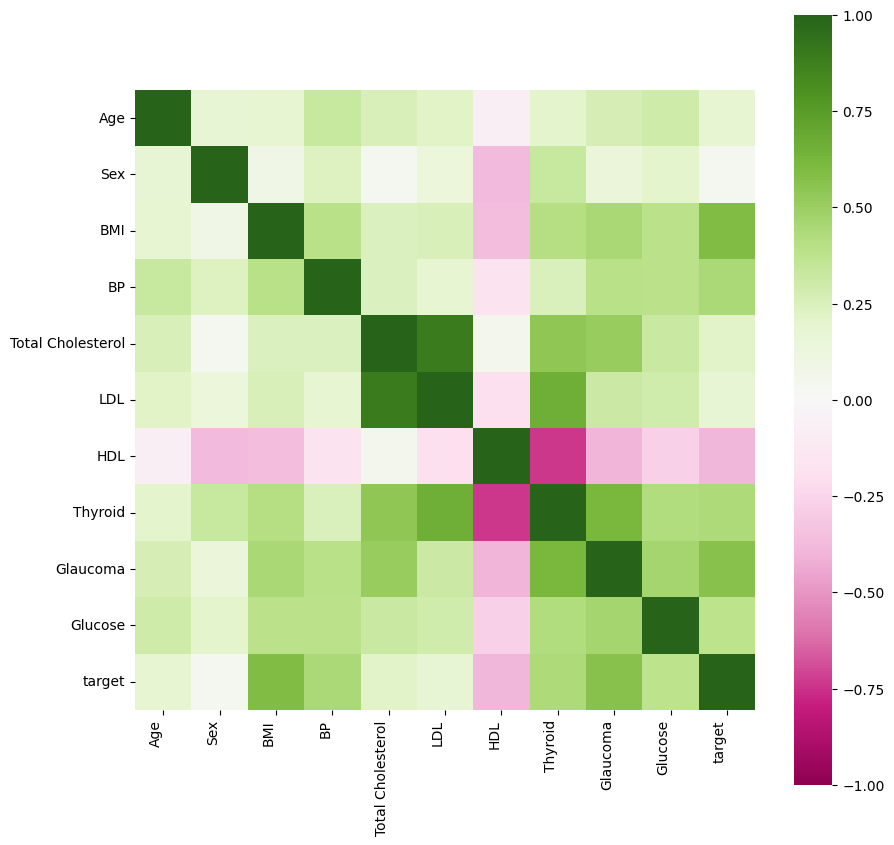

In [45]:
# ヒートマップを作成

import matplotlib.pyplot as plt
import seaborn as sns

corr = df_data.corr()

f, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(
    corr, 
    vmin=-1, vmax=1, center=0,
    cmap="PiYG",
    square=True,
    ax=ax
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=90,
    horizontalalignment='right'
)

# HDLだけ傾向が異なる

In [46]:
# 線形回帰モデルの作成

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 訓練/テストデータに分割
# テストデータのサイズは20%

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 線形回帰による予測

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 予測精度を検証
# その前にベース(=単なる平均を出力)を設定

y_base = np.median(y_test)

# ベースのMAEの計算

mae = np.mean(np.abs(y_test - y_base))
print(mae)

62.21348314606742


In [47]:
# ベースのRMSE

import math
from sklearn.metrics import mean_squared_error

rmse = math.sqrt(mean_squared_error(y_test, [y_base for _ in range(len(y_test))]))
print(rmse)

74.69646442605439


In [48]:
# ベースのMAPE

mape = np.mean(np.abs(y_test - y_base) / y_test) * 100
print(mape)

51.586778522876116


In [49]:
# 線形回帰のMAE

y_pred = lr_model.predict(X_test)
mae = np.mean(np.abs(y_test - y_pred))
print(mae)

42.794094679599944


In [50]:
# 線形回帰のRMSE

rmse = math.sqrt(mean_squared_error(y_test, y_pred))
print(rmse)

53.85344583676593


In [51]:
# 線形回帰のMAPE

mape = np.mean(np.abs(y_test - y_pred) / y_test) * 100
print(mape)

37.499826367561134


Text(0, 0.5, 'Features')

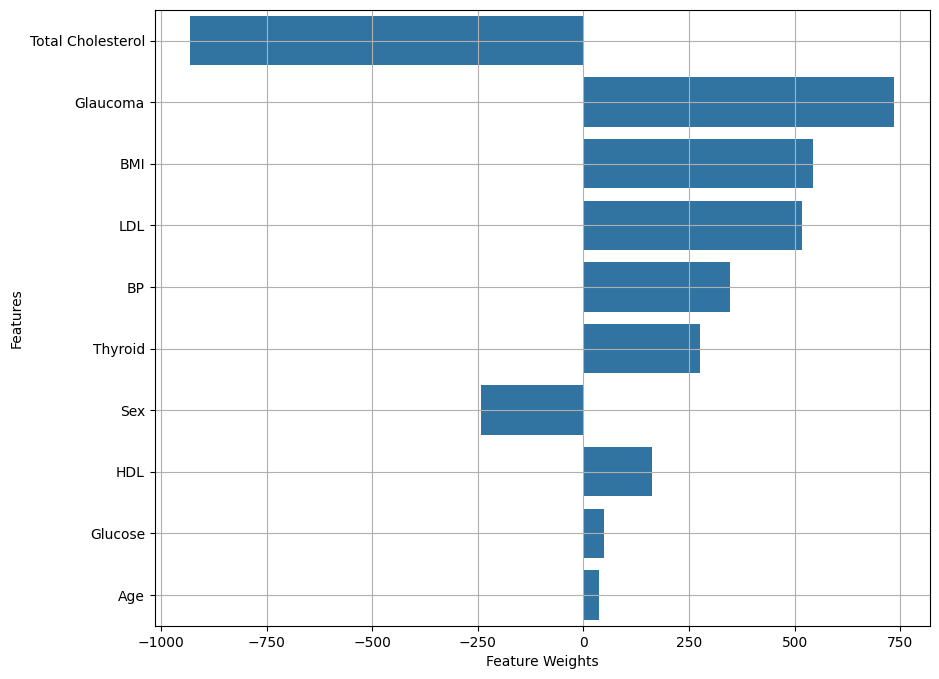

In [52]:
# 線形回帰の特徴量の重要度

weights = lr_model.coef_
feature_importance_idx = np.argsort(np.abs(weights))[::-1]
feature_importance = [feature_names[idx] for idx in feature_importance_idx]
feature_importance_values = [weights[idx] for idx in feature_importance_idx]
f, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x=feature_importance_values, y=feature_importance, ax=ax)
ax.grid(True)
ax.set_xlabel('Feature Weights')
ax.set_ylabel('Features')

# 正負よりもバーの長さが重要
# 考察: total cholesterolが多いと糖尿病のリスクが下がる??どういうこと??

#### 決定木モデル

In [53]:
# 決定木モデルによる予測
# 深さ無制限/深さ3までの2種類を用意

from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(max_depth=None, random_state=42)
dt_model_depth3 = DecisionTreeRegressor(max_depth=3, random_state=42)

dt_model.fit(X_train, y_train)
dt_model_depth3.fit(X_train, y_train)

# 深さ無制限の決定木のMAE

y_pred = dt_model.predict(X_test)
mae = np.mean(np.abs(y_test - y_pred))
print(mae)

54.52808988764045


In [54]:
# 深さ3までの決定木のMAE

y_pred_depth3 = dt_model_depth3.predict(X_test)
mae_depth3 = np.mean(np.abs(y_test - y_pred_depth3))
print(mae_depth3)

48.0965923002249


In [55]:
# 深さ3までの決定木のRMSE

rmse_depth3 = math.sqrt(mean_squared_error(y_test, y_pred_depth3))
print(rmse_depth3)

59.60454104616319


In [56]:
# 深さ3までの決定木のMAPE

mape_depth3 = np.mean(np.abs(y_test - y_pred_depth3) / y_test) * 100
print(mape_depth3)

43.0691295558855


In [57]:
# 決定木を描画するためのライブラリをインストール

!pip install pydotplus


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


Text(0, 0.5, 'Features')

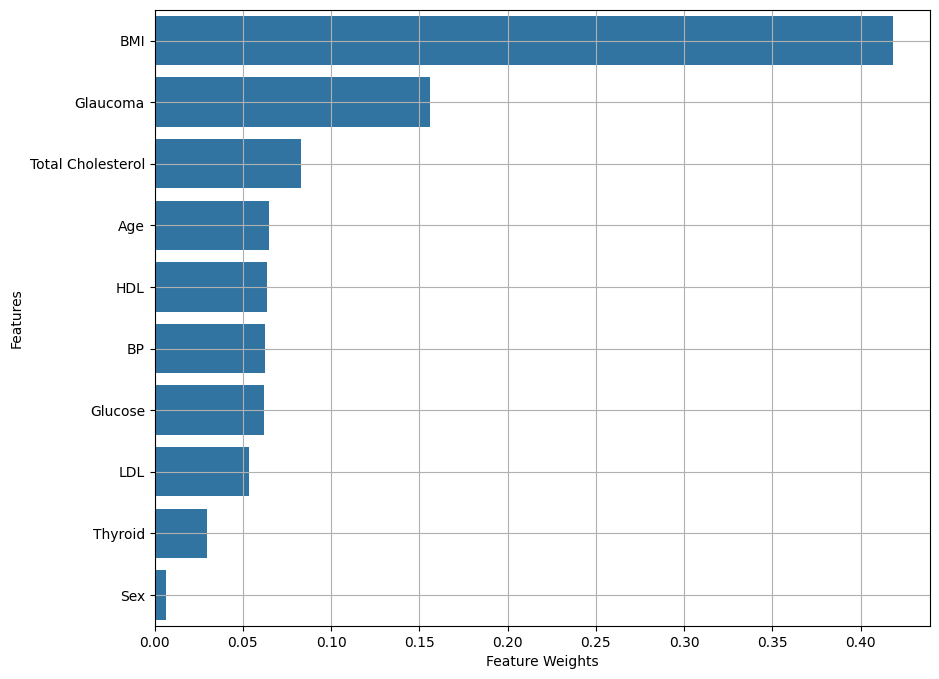

In [58]:
# 決定木における特徴量の重要度

weights = dt_model.feature_importances_
feature_importance_idx = np.argsort(np.abs(weights))[::-1]
feature_importance = [feature_names[idx] for idx in feature_importance_idx]
feature_importance_values = [weights[idx] for idx in feature_importance_idx]
f, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x=feature_importance_values, y=feature_importance, ax=ax)
ax.grid(True)
ax.set_xlabel('Feature Weights')
ax.set_ylabel('Features')

In [59]:
!pip install pygam


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


#### 一般化加法モデル(GAM)で予測

In [64]:
# GAMによる予測モデルの構築
# それぞれの項目の3次のスプラインまで考慮

from pygam import LinearGAM, s, te, f
import numpy as np
from scipy.sparse import issparse

# 疎行列なら dense に変換、そうでなければそのまま使う
if issparse(X_train):
    X_train_dense = X_train.toarray()
else:
    X_train_dense = X_train

gam = LinearGAM(s(0) + f(1) + s(2) + s(3) + s(4) + s(5) + s(6) + s(7) + s(8) + s(9), n_splines=35)
gam.gridsearch(X_train, y_train)
gam.summary()

# 性別だけはカテゴリ変数なのでここだけf(1)

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--


AttributeError: 'csr_matrix' object has no attribute 'A'

In [ ]:
# GAMのMAE

y_pred = gam.predict(X_test)
mae = np.mean(np.abs(y_test - y_pred))
print(mae)

In [ ]:
# GAMのRMSE

rmse = math.sqrt(mean_squared_error(y_test, y_pred))
print(rmse)

In [ ]:
# GAMのMAPE

mape = np.mean(np.abs(y_test - y_pred) / y_test) * 100
print(mape)

In [ ]:
# GAMの解釈

grid_locs1 = [(0, 0), (0, 1), (1, 0), (1, 1)]
fig, ax = plt.subplots(2, 2, figsize=(10, 8))
for i, feature in enumerate(feature_names[:4]):
    gl = grid_locs1[i]
    XX = gam.generate_X_grid(term=i)
    ax[gl[0], gl[1]].plot(XX[:, i], gam.partial_dependence(term=i, X=XX))
    ax[gl[0], gl[1]].plot(XX[:, i], gam.partial_dependence(term=i, X=XX, width=.95)[1], c='r', ls='--')
    ax[gl[0], gl[1]].set_xlabel('{0:s}'.format(feature))
    ax[gl[0], gl[1]].set_ylabel('f ({0:s})'.format(feature))
    
# 赤の点線が95%CI

In [ ]:
# 他の特徴量もチェック

grid_locs2 = [(0, 0), (0, 1), (1, 0), (1, 1), (2, 0), (2, 1)]
fig2, ax2 = plt.subplots(3, 2, figsize=(12, 12))
for i, feature in enumerate(feature_names[4:]):
    idx = i + 4
    gl = grid_locs2[i]
    XX = gam.generate_X_grid(term=idx)
    ax2[gl[0], gl[1]].plot(XX[:, idx], gam.partial_dependence(term=idx, X=XX))
    ax2[gl[0], gl[1]].plot(XX[:, idx], gam.partial_dependence(term=idx, X=XX, width=.95)[1], c='r', ls='--')
    ax2[gl[0], gl[1]].set_xlabel('{0:s}'.format(feature))
    ax2[gl[0], gl[1]].set_ylabel('f ({0:s})'.format(feature))

# 点線の幅が広い=アテにならんということ